# Rationalising Priors

- Implementing my big algorithm for choosing priors and then fitting models with different values of k and combinations of the prior frequencies.
- Then implement the model comparison with Occam penalty. 
- Use validation for model selection and test set for testing.

In [ ]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.22, valid_split=0.59):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()


C:\Users\Joey\AppData\Local\Temp\ipykernel_78544\1075607332.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)


- Plot Lomb-Scargle and add FAPs

In [51]:
def FAP(N, M, P):
    '''
    N is the number of datapoints in the time series from which the LS periodogram is derived.
    M is the number of independent frequencies M approx T x (fmax-fmin), where T is the number of years of data you have
    P is the power for which the FAP is desired.
    '''
    return  1 - ((1 - (1 - (2*P / (N-1)))** ((N-3)/2)) ** M)

def invFAP(N, M, FAP):
    '''
    Returns the power threshold corresponding to a given FAP level.
    Inverse of FAP function above.
    '''
    single_trial = 1 - (1 - FAP) ** (1/M)
    P = (N-1)/2 * (1 - single_trial ** (2/(N-3)))
    
    return P


0.5190301090910391


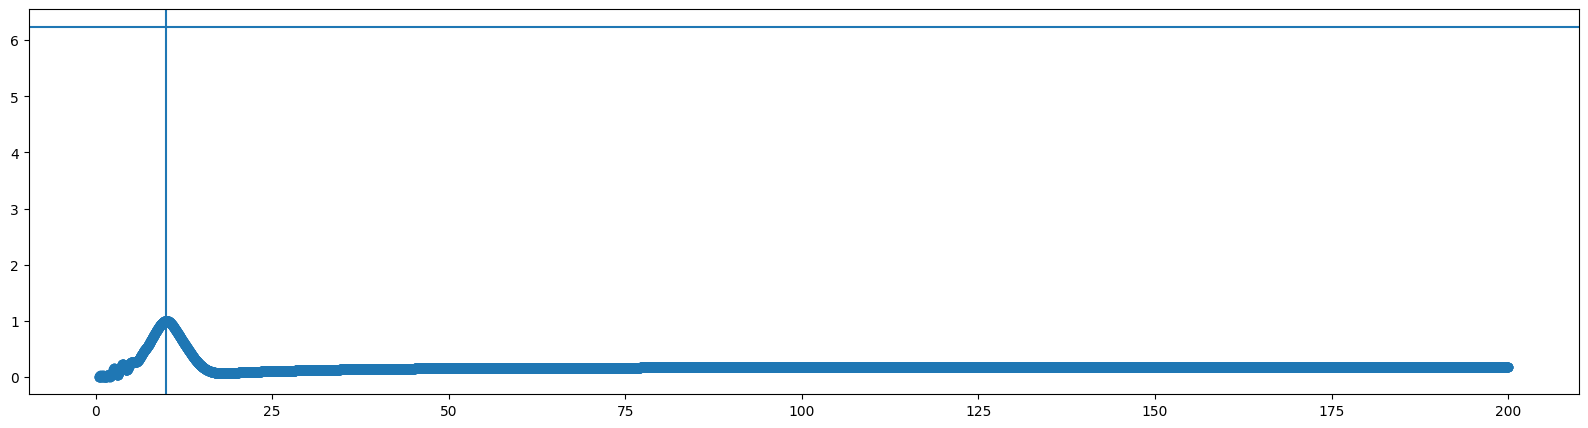

The best period is 10.017101710171017 years


In [59]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

train_df, valid_df, test_df = split_df(data)

# Define freq range
min_period = 0.5
max_period = 200
n_periods = 10000
periods = np.linspace(min_period, max_period, n_periods)
freq = 1 / periods


power = LombScargle(train_df['year'], train_df['sind']).power(freq)

# # Normalise the powers to frac of max to aid in peak finding
max_power = max(power)
power /= max_power

noise = np.percentile(power, 75)
print(noise * 3)

# Find the Lomb-Scargle peak
peaks, properties = find_peaks(power, height = 0., prominence= 5 * noise) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peaks]

# Things for calculating the FAP
N = len(train_df)
T = train_df['year'].max() - train_df['year'].min()
M = T * (1/min_period - 1/max_period)

# FAPs of note
FAPs = np.array([50]) / 100
power_invFAPs = invFAP(N = N, M = M, FAP = FAPs)
power_invFAPs /= max_power

# plot the thing
fig, ax = plt.subplots(1, figsize = (20,5))
ax.scatter(periods,power)
for peak_period in peak_periods:
    ax.axvline(peak_period)
for power_invFAP in power_invFAPs:
    ax.axhline(power_invFAP)
plt.show()

# print the best period
best_period = periods[np.argmax(power)]
print(f"The best period is {best_period} years")


- Generate fake data to test the LS thing